In [381]:
import pandas as pd
import zipfile
from sklearn.cluster import KMeans
from pandasql import sqldf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler
import numpy as np

## Data Ingestion (Bronze Layer)

In [2]:
# Load data from ZIP
with zipfile.ZipFile('data.nosync/online+retail+ii.zip','r') as zip:
    with zip.open('online_retail_II.xlsx') as excel_file:
        df_dict = pd.read_excel(excel_file,sheet_name=None)
        retail_bronze = pd.concat(df_dict.values(),axis=0,ignore_index=True)

## Silver Layer

In [3]:
print("=="*20)
print("Data Quality Check")
print("=="*20)
print("\nOverview:\n")
print(retail_bronze.info())
print("\n1. Missing Customer ID:")
print(f"   {retail_bronze['Customer ID'].isna().sum()*100/len(retail_bronze):.2f}%")
print("\n2. Missing Description:")
print(f"   {retail_bronze['Description'].isna().sum()*100/len(retail_bronze):.2f}%")
print("\n3. Duplicates Rows:")
print(f"   {retail_bronze.duplicated(subset=['Invoice','StockCode','Quantity','InvoiceDate',\
             'Price','Customer ID','Country']).sum()*100/len(retail_bronze):.2f}%")
print("\n4. Cancelled Orders:")
print(f"   {retail_bronze['Invoice'].astype(str).str.startswith('C').sum()*100\
/len(retail_bronze):.2f}%")
print("\n5. Negative Quantity:")
print(f"   {len(retail_bronze[retail_bronze['Quantity']<0])*100/len(retail_bronze):.2f}%")
print("\n6. Zero or Negative Price:")
print(f"   {len(retail_bronze[retail_bronze['Price']<=0])*100/len(retail_bronze):.2f}%")
print("\n7. Latest Invoice date:")
print(f"   {retail_bronze['InvoiceDate'].max()}")

Data Quality Check

Overview:

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB
None

1. Missing Customer ID:
   22.77%

2. Missing Description:
   0.41%

3. Duplicates Rows:
   3.22%

4. Cancelled Orders:
   1.83%

5. Negative Quantity:
   2.15%

6. Zero or Negative Price:
   0.58%

7. Latest Invoice date:
   2011-12-09 12:50:00


**Reason for data cleaning**
- Dropping Customer ID as we cannot cluster without it. coverted it to str as it a ID column.
- Not dropping missing rows in description as we will not use that for modelling.
- Removed cancelled orders with invoice starting with 'C' as this will distort results.
- Dropped 3.22% duplicates rows as this will inflate the results as these are system errors. Kepping only the last occurance.
- Negative Quantity are returns orders. Removing them otherwise will distort Frequency and Monetary.
- Removed zero/negative price as this could be data errors.
- Feature engineered TotalPrice for Monetary calculation.
- Remnoved blank spcace from columns name for data quality.
- Created reusable pipeline of all steps for easy debug and modifications.

In [76]:
def cleaning(df):
    df_clean = df.copy()
    
    df_clean.columns=df_clean.columns.str.replace(" ","")
    
    df_clean.dropna(subset = ["CustomerID"],inplace=True)
    df_clean['CustomerID']=df_clean['CustomerID'].astype(int).astype(str)
    df_clean['Description'] = df_clean['Description'].fillna('unknown')
    
    df_clean = df_clean.sort_values(by=['InvoiceDate']).\
                        drop_duplicates(subset=['Invoice','StockCode','Quantity',
                                                'InvoiceDate','Price','CustomerID',
                                                 'Country'],keep='last')
    
    anomalies = (df_clean['Invoice'].str.startswith('C')) | \
                (df_clean['Quantity']<0) | \
                (df_clean['Price']<=0)
    df_clean = df_clean[~anomalies]

    
    df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
    
    print(f"\nRows dropped after cleaning: {(len(df)-len(df_clean))*100/len(df):.2f}%")
    return df_clean.reset_index(drop=True)

retail_silver = cleaning(retail_bronze)

retail_silver.head()


Rows dropped after cleaning: 26.98%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## RFM Segmentation

- Recency: Used a hypothetical snap date which is ony day higher than the max invoice date to calculate recency. 
Most recent customer are more valuable customer which is 4 and 1 means inactive customer
- In pandas verion, assigned row number in ascending order and group that row number in 4 quartiles in decreasing order to assign recency in reverse order. 
- In SQL version, used 5-NITILE(5) of Recency value to reverse the bucket number to replicate same result.
- For Frequency and Monetary used asending order to bucket maximun distinct order count and total moneray values in lowest order.
- Pandas and SQL produce slightly different customer assignments due to:
  Pandas: Breaks ties using row position (rank method='first')
  SQL: Keeps ties together (NTILE behavior)

### Python Version

In [396]:
snap_date = retail_silver['InvoiceDate'].max()+pd.Timedelta(days=1)

rfm = retail_silver.groupby('CustomerID',as_index=False).agg(
    Recency=("InvoiceDate",lambda x: (snap_date-x.max()).days),
    Frequency = ("Invoice","nunique"),
    Monetary = ("TotalPrice","sum")
)

rfm['Recency_score'] = pd.qcut(rfm['Recency'].rank(method='first'),q=4,labels=[4,3,2,1]).astype(int) # Converting from catagorial to Int 
rfm['Frequency_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=4,labels=[1,2,3,4]).astype(int)
rfm["Monetary_score"]=pd.qcut(rfm['Monetary'].rank(method='first'),q=4,labels=[1,2,3,4]).astype(int)
rfm["RFM_Segment"]=rfm[['Recency_score','Frequency_score',"Monetary_score"]].sum(axis=1)\
                                    .map(lambda x: 'Gold' if x>=9 else
                                                   "Bronze" if x >=5 else
                                                   "Lost")

print("=="*30)
print("Distribution of RFM")
print("=="*30)
print(rfm.describe())

Distribution of RFM
           Recency    Frequency       Monetary  Recency_score  \
count  5878.000000  5878.000000    5878.000000    5878.000000   
mean    201.331916     6.289384    2955.810211       2.500000   
std     209.338707    13.009406   14440.288735       1.118281   
min       1.000000     1.000000       2.950000       1.000000   
25%      26.000000     1.000000     342.280000       1.250000   
50%      96.000000     3.000000     867.740000       2.500000   
75%     380.000000     7.000000    2248.305000       3.750000   
max     739.000000   398.000000  580987.040000       4.000000   

       Frequency_score  Monetary_score  
count      5878.000000     5878.000000  
mean          2.500000        2.500000  
std           1.118281        1.118281  
min           1.000000        1.000000  
25%           1.250000        1.250000  
50%           2.500000        2.500000  
75%           3.750000        3.750000  
max           4.000000        4.000000  


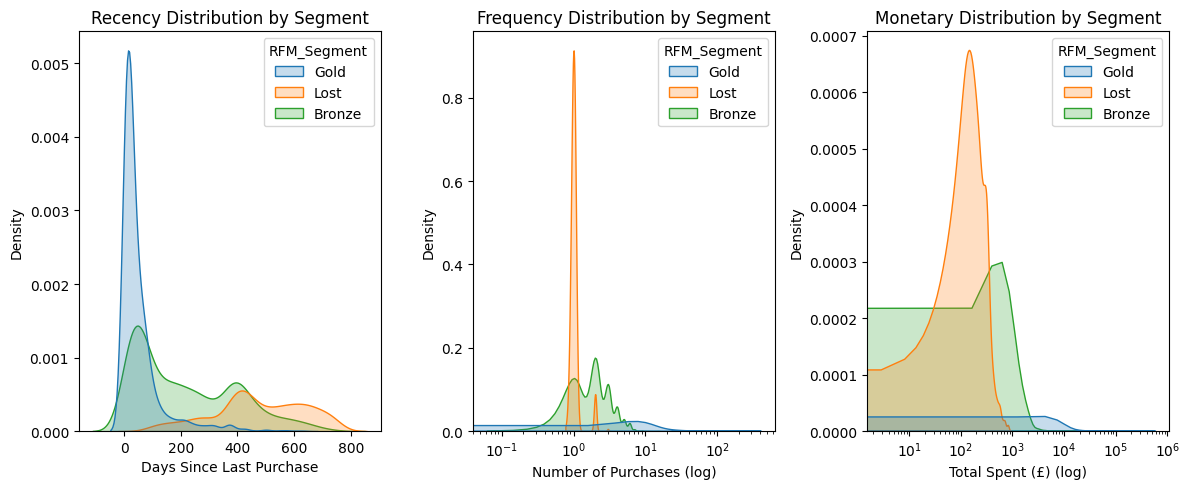

In [395]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,5))
sns.kdeplot(x="Recency",data=rfm,hue='RFM_Segment',fill= True,ax=ax1)
sns.kdeplot(x="Frequency",data=rfm,hue='RFM_Segment',fill= True,ax=ax2)
sns.kdeplot(x="Monetary",data=rfm,hue='RFM_Segment',fill= True,ax=ax3)
ax1.set_title('Recency Distribution by Segment')
ax1.set_xlabel('Days Since Last Purchase')
ax2.set_title('Frequency Distribution by Segment')
ax2.set_xlabel('Number of Purchases (log)')
ax2.set_xscale("log")
ax3.set_title('Monetary Distribution by Segment')
ax3.set_xlabel('Total Spent (£) (log)')
ax3.set_xscale("log")
plt.tight_layout()
plt.show()

**Key Insight:** 

- Having Lost Segment dominates in Frequeny =1 and low Monetary indicates one-time buyers didnot came back in last one year. we need more win-back approachs like discounts.

- Gold Segment are recent buyers with high Frequency and Monetary purchase pattern; Reward them with loyalty programme.

- Frequency & Monetary are highly right skewed with significant outliers in Monetary (max £580,987).

**Preprocessing decision:** 

- log taransformation for skewness and for outliers will use Standard Scaler as KMeans works well on same mean/std.


In [390]:
scaler = StandardScaler()
scaled = scaler.fit_transform(np.log1p(rfm[['Recency','Frequency',"Monetary"]]))
print(pd.DataFrame(scaled,index=rfm.index,columns=['Recency','Frequency',"Monetary"]).describe().round(2))

       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean     -0.00       0.00      0.00
std       1.00       1.00      1.00
min      -2.41      -1.06     -3.93
25%      -0.74      -1.06     -0.71
50%       0.08      -0.20     -0.04
75%       0.95       0.65      0.65
max       1.38       5.48      4.66


### SQL Version

In [127]:
rfm_sql = sqldf("""
    
    WITH RFM AS (
    
    SELECT 
        CustomerID,
        CAST((SELECT JULIANDAY(MAX(InvoiceDate)) + 1 FROM retail_silver) - JULIANDAY(MAX(InvoiceDate)) AS INTEGER)
        AS Recency,
        COUNT(DISTINCT Invoice) AS Frequency,
        SUM(TotalPrice) AS Monetary
        
    FROM retail_silver
    
    GROUP BY CustomerID
    )
       SELECT *,
       
       CAST (5-NTILE(4) OVER (ORDER BY Recency) AS TEXT)  Recency_score,
       CAST (NTILE(4) OVER (ORDER BY Frequency) AS TEXT) Frequency_score,
       CAST  (NTILE(4) OVER (ORDER BY Monetary) AS TEXT)  Monetary_score
       
    FROM RFM;
    
""")

rfm_sql.head()

,CustomerID,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score
0,13298,1,1,360.00,4,1,2
1,12713,1,1,848.55,4,2,2
2,13404,1,2,252.49,4,2,1
3,16322,1,2,326.75,4,2,1
4,17668,1,2,347.75,4,2,2


In [138]:
rfm_sql[rfm_sql["Recency"]==rfm_sql["Recency"].min()]["Recency_score"].unique()

<ArrowStringArray>
['4']
Length: 1, dtype: str

## Cohort Analysis: Time

In [ ]:
retail_clean['invoice_month']=retail_clean['invoicedate'].dt.to_period("M").dt.to_timestamp()
retail_clean['cohort_month']=retail_clean.groupby("customer_id")["invoice_month"].transform("min")

In [ ]:
# Cohort based on month
retail_clean["cohort_index"]= (retail_clean['invoice_month'].dt.year-retail_clean['cohort_month'].dt.year)*12 +\
                              (retail_clean['invoice_month'].dt.month-retail_clean['cohort_month'].dt.month)

- Cohot month fixed that is when they purchased for the first time
- Cohort index how many month since they joined.

## Counting monthly active customers in cohorts

In [ ]:
#wider format
cohots_counts=retail_clean.pivot_table(values="customer_id",
                                       index="cohort_month",
                                       columns='cohort_index',
                                       aggfunc='nunique',
                                       fill_value=0)
cohort_size=cohots_counts.iloc[:,0] # how may custmer at the 
retention = cohots_counts.divide(cohort_size,axis=0).round(3)*100

In [ ]:
cohort_size=cohots_counts.iloc[:,0] # how may custmer at the 
retention = cohots_counts.divide(cohort_size,axis=0).round(3)*100
retention.index=retention.index.strftime("%Y-%m")
plt.figure(figsize=(25,10))
plt.title('Retention Rate Percentage')
sns.heatmap(data=retention,
           cmap="BuGn",
           annot=True,
           fmt=".0f",
           vmin=0,
           vmax=40,
           linewidths=0.5)
plt.show()

- Retained 35% after first month; after two years still 20% so older customer has best loaylty generlly have more retention rate
- Retentate stabilize after the first drop in first month.
- columns wise all new customers acquired that month, how many came back just one month later?

- left to right is loyanty or retention
- top to bottom how new customer is adding
- Diagonally occation, chrustmas effect

In [ ]:
plt.scatter(RFM.iloc[:,3],RFM.iloc[:,1],label=RFM.iloc[:,-1])

In [119]:
# Check what scores exist in pandas
print("Pandas - Unique Recency scores:")
print(rfm['Recency_score'].unique())
print(rfm['Recency_score'].value_counts().sort_index())

print("\nPandas - Data types:")
print(rfm['Recency_score'].dtype)

Pandas - Unique Recency scores:
[2 4 3 1]
Recency_score
1    1470
2    1469
3    1469
4    1470
Name: count, dtype: int64

Pandas - Data types:
int64
